# 🇰🇷→🇺🇸 Korean-English Seq2Seq 번역기

이 노트북은 **Bahdanau Attention 기반 Seq2Seq 모델**로 한국어 문장을 영어 문장으로 생성합니다.  
단순 토큰 예측이 아니라, `<start>`에서 시작해 `<end>`가 나올 때까지 영어 문장을 **차례대로 완성**하는 구조입니다.

---

## 1. 이 노트북에서 하는 일

```text
한국어 문장
  ↓
한국어 전처리 + MeCab 형태소 분석
  ↓
한국어 토큰을 정수 ID로 변환
  ↓
Encoder가 한국어 문장 전체를 읽음
  ↓
Decoder가 Attention으로 한국어 단어를 참고하면서 영어 단어를 하나씩 생성
  ↓
<end> 토큰을 만나면 문장 생성 종료
  ↓
영어 문장 후처리: 공백 정리, 문장 첫 글자 대문자화
```

---

## 2. 핵심 구조

| 구성 요소 | 역할 |
|---|---|
| `CustomTokenizer` | 토큰과 정수 ID를 서로 변환합니다. `<pad>`, `<unk>`, `<start>`, `<end>`를 고정 ID로 관리합니다. |
| `Encoder` | 한국어 문장을 양방향 GRU로 읽고 문맥 벡터를 만듭니다. |
| `BahdanauAttention` | Decoder가 매 단어를 만들 때 한국어 문장의 어느 위치를 볼지 계산합니다. |
| `Decoder` | 이전 영어 단어와 Attention context를 이용해 다음 영어 단어를 예측합니다. |
| `Seq2SeqAttention` | Encoder와 Decoder를 연결해 전체 번역 흐름을 제어합니다. |

---

## 3. 이번 수정의 핵심

| 문제 | 수정 |
|---|---|
| 설명이 짧아 학습 흐름을 따라가기 어려움 | 각 셀에 목적, 입력, 출력, 주의점을 마크다운으로 보강했습니다. |
| 코드 주석이 부족함 | 텐서 shape, 학습 흐름, 함수 역할을 주석으로 자세히 달았습니다. |
| 문장 결과가 토큰 나열처럼 보임 | `detokenize_en()`을 추가해 영어 문장 공백과 대문자를 정리했습니다. |
| 번역 품질이 떨어질 수 있는 라벨 정렬 버그 | `outputs[1:]`와 `trg_label[:-1]`이 대응되도록 손실 계산을 수정했습니다. |
| 탐욕적 디코딩만 사용 | 선택적으로 사용할 수 있는 `beam_search_translate()`를 추가했습니다. |

---

## 4. 가장 중요한 수정: 라벨 정렬

기존 학습 코드는 다음처럼 정답이 한 칸 밀릴 수 있었습니다.

```text
Decoder 입력:  <start>  I      am      happy
모델 예측:       I      am     happy    <end>
정답 라벨:       I      am     happy    <end>
```

모델의 `outputs[1]`은 `<start>`를 보고 만든 첫 번째 예측입니다.  
따라서 `outputs[1]`은 `trg_label[0]`과 비교해야 합니다.  
이번 수정본에서는 이 정렬을 명확하게 맞췄습니다.


## Cell 1. 패키지 설치
KoNLPy(MeCab)을 설치합니다. **최초 1회만** 실행하면 됩니다.


In [15]:
# KoNLPy 설치 (MeCab 포함)
!pip install -q konlpy

## Cell 2. Import & 디바이스 설정
필요한 라이브러리를 불러오고, GPU 사용 가능 여부를 확인합니다.

- `tqdm.notebook` — Jupyter 전용 진행 막대 (셀 출력에 인라인으로 표시)
- `SEED` 고정 — `random`, `numpy`, `torch` 전부 동일 시드로 재현성 확보


In [16]:
import os
import re
import random
import urllib.request
import tarfile
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.notebook import tqdm   # Jupyter 전용 — 진행 막대 인라인 표시
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from konlpy.tag import Mecab

# ── 재현성을 위한 시드 고정 ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── GPU / CPU 자동 선택 ───────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")


사용 디바이스: cuda


## Cell 3. 하이퍼파라미터

이 셀은 실험 설정을 한곳에 모아둔 부분입니다.  
처음 실험할 때는 이 셀만 바꾸는 방식으로 진행하는 것이 안전합니다.

| 파라미터 | 의미 | 추천 방향 |
|---|---|---|
| `VOCAB_SIZE` | 사용할 최대 단어 수 | 너무 작으면 `<unk>`가 많아지고, 너무 크면 학습이 느려집니다. |
| `MAX_LEN` | 한 문장의 최대 토큰 길이 | 긴 문장을 많이 살리고 싶으면 늘립니다. 단, 메모리 사용량도 증가합니다. |
| `EMB_DIM` | 단어 임베딩 차원 | 클수록 표현력이 좋아지지만 학습 비용이 증가합니다. |
| `HID_DIM` | GRU hidden 차원 | 모델의 핵심 용량입니다. GPU가 약하면 256부터 시작합니다. |
| `DROPOUT` | 과적합 방지 비율 | 데이터가 적거나 검증 손실이 빨리 나빠지면 높입니다. |
| `BATCH_SIZE` | 한 번에 학습할 문장 수 | GPU 메모리가 부족하면 줄입니다. |
| `EPOCHS` | 최대 학습 횟수 | Early Stopping이 있으므로 넉넉하게 둬도 됩니다. |
| `VALID_RATIO` | 검증 데이터 비율 | 보통 0.1 또는 0.2를 사용합니다. |
| `CLIP` | Gradient Clipping 기준 | RNN 계열에서 기울기 폭발을 막기 위해 필요합니다. |


In [17]:
# ─────────────────────────────────────────────────────────────
# 1) 데이터 관련 설정
# ─────────────────────────────────────────────────────────────
VOCAB_SIZE  = 8_000    # 단어장 최대 크기. 상위 빈도 단어만 남깁니다.
MAX_LEN     = 40       # 한국어/영어 문장의 최대 토큰 길이입니다.
VALID_RATIO = 0.10     # 전체 데이터 중 검증 데이터 비율입니다.

# ─────────────────────────────────────────────────────────────
# 2) 모델 크기 설정
# ─────────────────────────────────────────────────────────────
EMB_DIM     = 128      # 단어를 몇 차원 벡터로 표현할지 결정합니다.
HID_DIM     = 256      # GRU hidden state 차원입니다.
DROPOUT     = 0.5      # 과적합 방지를 위한 드롭아웃 비율입니다.

# ─────────────────────────────────────────────────────────────
# 3) 학습 관련 설정
# ─────────────────────────────────────────────────────────────
BATCH_SIZE  = 128      # 한 번에 학습할 샘플 수입니다.
LR          = 5e-4     # Adam optimizer의 초기 학습률입니다.
EPOCHS      = 30       # 최대 학습 에폭 수입니다.
PATIENCE    = 5        # 검증 손실이 개선되지 않아도 기다릴 에폭 수입니다.
CLIP        = 1.0      # RNN 기울기 폭발 방지용 gradient clipping 기준입니다.

# Teacher Forcing은 초반에는 높게, 후반에는 낮게 둡니다.
# 초반: 정답 단어를 자주 보여주어 빠르게 학습합니다.
# 후반: 모델이 자기 예측을 이어가며 문장을 완성하도록 훈련합니다.
TF_START    = 1.0
TF_END      = 0.0
TF_DECAY    = 0.025    # epoch마다 teacher forcing을 얼마나 줄일지 결정합니다.

# ─────────────────────────────────────────────────────────────
# 4) 파일 경로
# ─────────────────────────────────────────────────────────────
DATASET_DIR = "datasets"
SAVE_PATH   = "best_model.pt"   # 검증 손실이 가장 낮은 모델 가중치 저장 경로입니다.

print("하이퍼파라미터 설정 완료 ✓")
print(f"VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, BATCH_SIZE={BATCH_SIZE}")
print(f"EPOCHS={EPOCHS}, LR={LR}, PATIENCE={PATIENCE}, CLIP={CLIP}")


하이퍼파라미터 설정 완료 ✓
VOCAB_SIZE=8000, MAX_LEN=40, BATCH_SIZE=128
EPOCHS=30, LR=0.0005, PATIENCE=5, CLIP=1.0


## Cell 4. 데이터 다운로드
[jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora) 의
한국어-영어 뉴스 병렬 코퍼스를 다운로드합니다.

- `korean-english-park.train.ko` — 한국어 원문
- `korean-english-park.train.en` — 영어 번역문


In [18]:
DATA_URL = (
    "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora"
    "/master/korean-english-news-v1/korean-english-park.train.tar.gz"
)

def download_data(dataset_dir: str = DATASET_DIR) -> tuple:
    """데이터 tar.gz 다운로드 → 압축 해제 → (ko경로, en경로) 반환."""
    os.makedirs(dataset_dir, exist_ok=True)
    tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

    if not os.path.exists(tar_path):   # 이미 다운로드된 경우 생략
        print("다운로드 중...")
        urllib.request.urlretrieve(DATA_URL, tar_path)
        print("다운로드 완료!")

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=dataset_dir)

    ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
    en_path = os.path.join(dataset_dir, "korean-english-park.train.en")
    return ko_path, en_path


ko_path, en_path = download_data()
print(f"KO: {ko_path}")
print(f"EN: {en_path}")


/tmp/ipykernel_127/3640354132.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=dataset_dir)


KO: datasets/korean-english-park.train.ko
EN: datasets/korean-english-park.train.en


## Cell 5. 전처리 함수
### 한국어 전처리 (`preprocess_ko`)
- 구두점(`? . ! ,`) 앞뒤에 공백 삽입 → MeCab이 구두점을 독립 토큰으로 분리하도록 유도
- 한글/영문/숫자/기본 구두점 이외 문자 제거

### 영어 전처리 (`preprocess_en`)
- 소문자 변환 + 구두점 분리 + 특수문자 제거
- `<start>` / `<end>` 토큰 부착 — 디코더가 시작/종료 위치를 학습하도록


In [19]:
def preprocess_ko(sentence: str) -> str:
    """한국어 문장 정규화."""
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)   # 구두점 분리
    sentence = re.sub(r"\s+", " ", sentence)              # 연속 공백 → 단일 공백
    # 한글/영문/숫자/구두점 이외 문자 제거
    sentence = re.sub(r"[^a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣0-9?.!,]+", " ", sentence)
    return sentence.strip()


def preprocess_en(sentence: str) -> str:
    """영어 문장 정규화 + BOS/EOS 토큰 부착."""
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    return f"<start> {sentence.strip()} <end>"   # BOS / EOS 부착


# ── 동작 확인 ────────────────────────────────────────────────────
print(f"KO: '{preprocess_ko('오바마는 대통령이다!')}'")
print(f"EN: '{preprocess_en('Obama is the president!')}'")


KO: '오바마는 대통령이다 !'
EN: '<start> obama is the president ! <end>'


## Cell 6. 데이터 로드 · 중복 제거 · 필터링

### 처리 순서
1. **파일 로드** — 줄 단위로 읽어 리스트로 저장
2. **중복 제거** — `zip` → `set` 으로 병렬 쌍을 유지하면서 중복 제거
3. **전처리 + MeCab 형태소 분석** — 한국어는 MeCab, 영어는 공백 분리
4. **길이 필터링** — 양쪽 모두 `MAX_LEN` 이하인 쌍만 유지


In [20]:
!pip install python-mecab-ko -q

In [22]:
# ============================================================
# 1. 라이브러리 import
# ============================================================

from mecab import MeCab
from tqdm import tqdm
import re


# ============================================================
# 2. MeCab 초기화
# ============================================================

mecab = MeCab()

print("[MeCab 테스트]")
print(mecab.morphs("안녕하세요. 형태소 분석 테스트입니다."))


# ============================================================
# 3. 전처리 함수
# ============================================================

def preprocess_ko(text: str) -> str:
    """
    한국어 문장 기본 전처리.
    """
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


def preprocess_en(text: str) -> str:
    """
    영어 문장 기본 전처리.
    """
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


# ============================================================
# 4. 병렬 코퍼스 로드 / 중복 제거 / 토크나이징 / 길이 필터링
# ============================================================

def load_and_filter(ko_path: str, en_path: str, max_len: int = MAX_LEN) -> tuple:
    """
    병렬 코퍼스 로드 → 중복 제거 → 전처리 → 토크나이징 → 길이 필터링.
    """

    # 1) 파일 로드
    with open(ko_path, encoding="utf-8") as f:
        ko_raw = f.read().splitlines()

    with open(en_path, encoding="utf-8") as f:
        en_raw = f.read().splitlines()

    print(f"원본 KO 데이터: {len(ko_raw):,}개")
    print(f"원본 EN 데이터: {len(en_raw):,}개")

    # 병렬 데이터 개수 검증
    if len(ko_raw) != len(en_raw):
        raise ValueError(
            f"KO/EN 문장 수가 다릅니다. KO={len(ko_raw):,}, EN={len(en_raw):,}"
        )

    # 2) 병렬 쌍 중복 제거
    # set은 순서를 섞으므로 dict.fromkeys 사용
    cleaned = list(dict.fromkeys(zip(ko_raw, en_raw)))

    print(f"중복 제거 후: {len(cleaned):,}개")

    if len(cleaned) == 0:
        raise ValueError("중복 제거 후 남은 데이터가 없습니다.")

    # 3) 전처리 + 토크나이징 + 길이 필터링
    filtered_ko, filtered_en = [], []

    for ko, en in tqdm(cleaned, total=len(cleaned), desc="전처리 중"):
        ko = preprocess_ko(ko)
        en = preprocess_en(en)

        # 빈 문장 제거
        if not ko or not en:
            continue

        # python-mecab-ko 방식
        ko_tok = mecab.morphs(ko)
        en_tok = en.split()

        # 토큰화 후 빈 문장 제거
        if len(ko_tok) == 0 or len(en_tok) == 0:
            continue

        # 영어 쪽은 이후 <sos>, <eos> 추가를 고려해 max_len + 2 허용
        if len(ko_tok) <= max_len and len(en_tok) <= max_len + 2:
            filtered_ko.append(ko_tok)
            filtered_en.append(en_tok)

    print(f"길이 필터 후: {len(filtered_ko):,}개")

    if len(filtered_ko) == 0:
        raise ValueError("길이 필터 후 남은 데이터가 없습니다. MAX_LEN을 늘려보세요.")

    return filtered_ko, filtered_en


# ============================================================
# 5. 실행
# ============================================================

filtered_ko, filtered_en = load_and_filter(ko_path, en_path)


# ============================================================
# 6. 샘플 확인
# ============================================================

print("\n[샘플]")
print(f"KO: {filtered_ko[0]}")
print(f"EN: {filtered_en[0]}")

[MeCab 테스트]
['안녕', '하', '세요', '.', '형태소', '분석', '테스트', '입니다', '.']
원본 KO 데이터: 94,123개
원본 EN 데이터: 94,123개
중복 제거 후: 78,968개


전처리 중: 100%|██████████| 78968/78968 [00:27<00:00, 2915.90it/s]

길이 필터 후: 62,262개

[샘플]
KO: ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '"', '이것', '보다', '뛰어날', '수', '있', '느냐', '?', '"']
EN: ['much', 'of', 'personal', 'computing', 'is', 'about', '"can', 'you', 'top', 'this?"']


## Cell 7. CustomTokenizer

단어장(vocabulary)을 구축하고 토큰 ↔ 정수 ID 변환을 담당합니다.

### 특수 토큰
| 토큰 | ID | 역할 |
|---|---|---|
| `<pad>` | 0 | 짧은 시퀀스를 같은 길이로 맞추기 위한 패딩 |
| `<unk>` | 1 | 단어장에 없는 미등록 단어 |
| `<start>` | 2 | 디코더 시퀀스 시작 신호 (BOS) |
| `<end>` | 3 | 디코더 시퀀스 종료 신호 (EOS) |

### 버그 수정
기존 코드에서 `<start>`, `<end>` 가 영어 문장에 포함되어 있어 일반 단어로 카운트되고,
ID가 덮어씌워지는 문제가 있었습니다. `fit()` 에서 특수 토큰을 counter에서 제거하도록 수정했습니다.


In [23]:
class CustomTokenizer:
    """
    토큰 리스트를 정수 ID 리스트로 바꾸고, 다시 문자열로 복원하는 클래스입니다.

    중요한 점
    --------
    - <pad>   : 길이가 짧은 문장을 같은 길이로 맞출 때 사용합니다.
    - <unk>   : 단어장에 없는 단어를 대신합니다.
    - <start> : 디코더가 문장 생성을 시작할 때 사용하는 토큰입니다.
    - <end>   : 디코더가 문장 생성을 끝낼 때 사용하는 토큰입니다.

    특수 토큰 ID를 고정해야 학습/추론 코드가 안정적으로 동작합니다.
    """

    PAD, UNK, BOS, EOS = 0, 1, 2, 3
    _SPECIALS = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}

    def __init__(self, vocab_size: int):
        self.vocab_size = vocab_size
        self.word2idx = dict(self._SPECIALS)
        self.idx2word = {v: k for k, v in self._SPECIALS.items()}

    def fit(self, tokenized_texts: list) -> None:
        """빈도 순 상위 단어로 vocabulary를 구축합니다."""
        counter = Counter(token for text in tokenized_texts for token in text)

        # <start>, <end>는 영어 데이터에 실제로 들어 있습니다.
        # 이 토큰들이 일반 단어처럼 다시 등록되면 고정 ID가 깨질 수 있으므로 제거합니다.
        for special in self._SPECIALS.keys():
            counter.pop(special, None)

        n_slots = self.vocab_size - len(self._SPECIALS)
        for idx, (word, _) in enumerate(counter.most_common(n_slots), start=len(self._SPECIALS)):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, tokens: list, max_len: int) -> list:
        """
        토큰 리스트를 고정 길이 정수 ID 리스트로 변환합니다.

        예시
        ----
        tokens = ["i", "am", "happy"]
        ids    = [12, 43, 89, 0, 0, 0, ...]
        """
        ids = [self.word2idx.get(token, self.UNK) for token in tokens]
        ids = ids[:max_len]
        ids += [self.PAD] * (max_len - len(ids))
        return ids

    def decode(self, ids: list) -> str:
        """
        정수 ID 리스트를 다시 문자열로 복원합니다.

        - <end>를 만나면 문장 생성을 종료합니다.
        - <pad>, <unk>, <start>는 최종 문장에서 제외합니다.
        """
        tokens = []
        for idx in ids:
            if idx == self.EOS:
                break
            if idx in (self.PAD, self.UNK, self.BOS):
                continue
            tokens.append(self.idx2word.get(idx, ""))
        return " ".join(tokens)

    def __len__(self) -> int:
        return len(self.word2idx)


# ── 단어장 구축 ──────────────────────────────────────────────────
ko_tokenizer = CustomTokenizer(VOCAB_SIZE)
ko_tokenizer.fit(filtered_ko)

en_tokenizer = CustomTokenizer(VOCAB_SIZE)
en_tokenizer.fit(filtered_en)

print(f"KO 단어장: {len(ko_tokenizer):,}개")
print(f"EN 단어장: {len(en_tokenizer):,}개")
print("특수 토큰 확인:", {k: en_tokenizer.word2idx[k] for k in ["<pad>", "<unk>", "<start>", "<end>"]})


KO 단어장: 8,000개
EN 단어장: 8,000개
특수 토큰 확인: {'<pad>': 0, '<unk>': 1, '<start>': 2, '<end>': 3}


## Cell 8. Dataset & DataLoader

### 타겟 시퀀스 분리 방식
```
원본:      [ <start>  w1   w2   w3  <end> ]
trg_input: [ <start>  w1   w2   w3  ]      ← 디코더 입력 (마지막 제거)
trg_label: [          w1   w2   w3  <end> ] ← 정답 레이블 (<start> 제거)
```
디코더는 `<start>`를 받아 `w1`을 예측하고, `w1`을 받아 `w2`를 예측하는 식으로 학습합니다.


In [24]:
class KoEnDataset(Dataset):
    """
    한국어-영어 병렬 코퍼스 Dataset.

    __getitem__ 반환값
    ------------------
    src       : (MAX_LEN,)  한국어 정수 시퀀스
    trg_input : (MAX_LEN,)  디코더 입력  [<start>, w1, ..., wN]
    trg_label : (MAX_LEN,)  정답 레이블  [w1, ..., wN, <end>]
    """

    def __init__(self, ko_data, en_data, ko_tok, en_tok, max_len):
        self.ko_data = ko_data
        self.en_data = en_data
        self.ko_tok  = ko_tok
        self.en_tok  = en_tok
        self.max_len = max_len

    def __len__(self):
        return len(self.ko_data)

    def __getitem__(self, idx):
        src = self.ko_tok.encode(self.ko_data[idx], self.max_len)

        # max_len+1 길이로 인코딩 후 슬라이싱으로 input/label 분리
        trg_full  = self.en_tok.encode(self.en_data[idx], self.max_len + 1)
        trg_input = trg_full[:-1]   # 마지막 제거 → 디코더 입력
        trg_label = trg_full[1:]    # 첫 번째(<start>) 제거 → 정답

        return (
            torch.tensor(src,       dtype=torch.long),
            torch.tensor(trg_input, dtype=torch.long),
            torch.tensor(trg_label, dtype=torch.long),
        )


# ── 훈련 / 검증 분리 ─────────────────────────────────────────────
full_dataset = KoEnDataset(filtered_ko, filtered_en, ko_tokenizer, en_tokenizer, MAX_LEN)
valid_size   = int(len(full_dataset) * VALID_RATIO)
train_size   = len(full_dataset) - valid_size

train_set, valid_set = random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(SEED),
)

# pin_memory=True — GPU 전송 속도 향상
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train: {len(train_set):,}개  |  Valid: {len(valid_set):,}개")

# 배치 shape 확인
src_b, trg_in_b, trg_lb_b = next(iter(train_loader))
print(f"\n배치 shape — src: {tuple(src_b.shape)}, trg_input: {tuple(trg_in_b.shape)}, trg_label: {tuple(trg_lb_b.shape)}")


Train: 56,036개  |  Valid: 6,226개

배치 shape — src: (128, 40), trg_input: (128, 40), trg_label: (128, 40)


### 정답 라벨 정렬 확인

이 노트북에서 가장 중요한 부분입니다.

```text
영어 원본 토큰:  <start>   I      am      happy    <end>
trg_input:       <start>   I      am      happy
trg_label:       I         am     happy   <end>
```

학습 시 `outputs[1]`은 `<start>`를 입력받아 만든 첫 번째 예측입니다.  
따라서 `outputs[1]`은 `trg_label[0]`과 비교해야 합니다.

즉 손실 계산은 다음 대응이 맞습니다.

```text
outputs[1:]  ↔  trg_label[:-1]
```

기존처럼 `outputs[1:] ↔ trg_label[1:]`로 계산하면 정답이 한 칸 밀려 학습됩니다.  
이 버그는 번역 품질과 문장 완성 능력을 크게 떨어뜨립니다.


## Cell 9. 모델 정의 — Encoder

양방향 GRU(Bidirectional GRU)로 소스 시퀀스 전체를 읽어 두 가지를 반환합니다.

- **`encoder_outputs`** `(src_len, batch, hid_dim×2)` — 각 토큰 위치의 문맥 표현 (Attention에서 사용)
- **`hidden`** `(batch, hid_dim)` — 인코더 최종 상태 → 디코더 초기 hidden으로 전달

양방향이므로 forward/backward hidden을 `Linear`로 합쳐 `hid_dim` 차원으로 압축합니다.


In [25]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout):
        super().__init__()
        # padding_idx: <pad> 위치 임베딩을 0으로 고정 (역전파 없음)
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=CustomTokenizer.PAD)
        # 양방향 GRU — 출력 차원이 hid_dim * 2
        self.rnn       = nn.GRU(emb_dim, hid_dim, bidirectional=True, batch_first=False)
        # 양방향 hidden(hid*2) → 단방향 hidden(hid) 으로 압축
        self.fc        = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.dropout(self.embedding(src))
        # embedded: (src_len, batch, emb_dim)

        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch, hid_dim*2)
        # hidden:  (2, batch, hid_dim) ← [forward, backward]

        # forward hidden[-2] + backward hidden[-1] concat 후 압축
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))
        # hidden: (batch, hid_dim)

        return outputs, hidden


## Cell 10. 모델 정의 — BahdanauAttention

디코더가 매 스텝마다 **"소스의 어느 위치에 집중할지"** 를 계산합니다.

### 계산 흐름
```
decoder hidden  (batch, hid_dim)
encoder outputs (src_len, batch, hid_dim×2)
       ↓ concat + Linear + tanh  →  energy  (batch, src_len, hid_dim)
       ↓ Linear(hid_dim → 1)     →  score   (batch, src_len)
       ↓ softmax                 →  weight  (batch, src_len)  ← 합이 1
```
이 weight로 encoder_outputs를 가중합 → **context vector** 생성


In [26]:
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        # 디코더 hidden(hid) + 인코더 출력(hid*2) → 입력 차원 = hid*3
        self.attn = nn.Linear(hid_dim * 3, hid_dim)
        # 에너지 스코어를 스칼라 하나로 압축
        self.v    = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden:          (batch, hid_dim)
        # encoder_outputs: (src_len, batch, hid_dim*2)
        src_len = encoder_outputs.size(0)

        # 디코더 hidden을 src_len 번 복사
        hidden_exp = hidden.unsqueeze(1).repeat(1, src_len, 1)
        # hidden_exp: (batch, src_len, hid_dim)

        enc_out = encoder_outputs.permute(1, 0, 2)
        # enc_out: (batch, src_len, hid_dim*2)

        # concat → Linear → tanh 로 에너지 계산
        energy    = torch.tanh(self.attn(torch.cat((hidden_exp, enc_out), dim=2)))
        attention = self.v(energy).squeeze(2)
        # attention: (batch, src_len) ← 각 소스 위치의 raw score

        return torch.softmax(attention, dim=1)
        # 반환: (batch, src_len) ← 소스 위치별 가중치 (합 = 1)


## Cell 11. 모델 정의 — Decoder

매 스텝마다 하나의 영어 토큰을 생성합니다.

### 한 스텝의 계산 흐름
```
이전 토큰 임베딩 (1, batch, emb_dim)
       ↓
Attention weight → context vector (1, batch, hid_dim×2)
       ↓ concat
GRU 입력: [임베딩 + context]  (1, batch, emb_dim + hid_dim×2)
       ↓ GRU
새 hidden (batch, hid_dim)
       ↓ concat [GRU출력 + context + 임베딩]
Linear → 다음 토큰 확률분포 (batch, vocab_size)
```


In [27]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention, dropout):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=CustomTokenizer.PAD)
        # GRU 입력: 임베딩(emb) + context(hid*2)
        self.rnn       = nn.GRU(emb_dim + hid_dim * 2, hid_dim, batch_first=False)
        # 최종 예측: GRU출력(hid) + context(hid*2) + 임베딩(emb) 결합
        self.fc_out    = nn.Linear(hid_dim * 3 + emb_dim, output_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, token, hidden, encoder_outputs):
        # token: (batch,) → (1, batch) unsqueeze (GRU는 3D 입력 필요)
        token    = token.unsqueeze(0)
        embedded = self.dropout(self.embedding(token))
        # embedded: (1, batch, emb_dim)

        # ── Attention ────────────────────────────────────────────
        attn_w  = self.attention(hidden, encoder_outputs)
        # attn_w: (batch, src_len)

        # 가중합으로 context vector 계산
        context = torch.bmm(
            attn_w.unsqueeze(1),                          # (batch, 1, src_len)
            encoder_outputs.permute(1, 0, 2)              # (batch, src_len, hid*2)
        ).permute(1, 0, 2)
        # context: (1, batch, hid_dim*2)

        # ── GRU ──────────────────────────────────────────────────
        rnn_out, hidden = self.rnn(
            torch.cat((embedded, context), dim=2),        # (1, batch, emb+hid*2)
            hidden.unsqueeze(0)
        )
        hidden = hidden.squeeze(0)                        # (batch, hid_dim)

        # ── 다음 토큰 예측 ────────────────────────────────────────
        pred = self.fc_out(
            torch.cat((rnn_out.squeeze(0),                # (batch, hid_dim)
                       context.squeeze(0),                # (batch, hid_dim*2)
                       embedded.squeeze(0)), dim=1)       # (batch, emb_dim)
        )
        # pred: (batch, output_dim)

        return pred, hidden, attn_w


## Cell 12. 모델 정의 — Seq2SeqAttention (전체 모델)

Encoder와 Decoder를 연결하는 최상위 모델입니다.

### Teacher Forcing
훈련 중 일정 확률(`teacher_forcing_ratio`)로 실제 정답 토큰을 다음 스텝 입력으로 사용합니다.

```
teacher_forcing_ratio = 1.0  →  항상 정답 입력 (빠른 수렴, 추론 불일치 위험)
teacher_forcing_ratio = 0.0  →  항상 예측 사용 (추론과 동일 조건)
teacher_forcing_ratio = 0.5  →  절충 (일반적 선택)
```

에폭이 늘수록 비율을 `1.0 → 0.0` 으로 점진적으로 낮춰 추론 능력을 키웁니다.

### 추론 모드 (`trg=None`)
`trg=None` 으로 호출하면 teacher forcing 없이 완전한 **auto-regressive** 디코딩을 수행합니다.
`<end>` 토큰이 예측되면 즉시 루프를 종료합니다.


In [28]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5, max_len=MAX_LEN):
        """
        Parameters
        ----------
        src                   : (src_len, batch)  소스 시퀀스
        trg                   : (trg_len, batch)  타겟 — None 이면 추론 모드
        teacher_forcing_ratio : 0.0 ~ 1.0
        max_len               : 추론 시 최대 생성 길이
        """
        # ── 인코딩 ──────────────────────────────────────────────
        encoder_outputs, hidden = self.encoder(src)
        # encoder_outputs: (src_len, batch, hid*2)
        # hidden:          (batch, hid_dim)

        trg_len  = trg.size(0) if trg is not None else max_len
        batch    = src.size(1)
        vocab_sz = self.decoder.fc_out.out_features

        # 모든 스텝의 출력을 저장할 텐서
        outputs   = torch.zeros(trg_len, batch, vocab_sz, device=self.device)
        attn_list = []

        # 첫 디코더 입력: <start> 토큰
        token = (trg[0] if trg is not None
                 else torch.full((batch,), CustomTokenizer.BOS,
                                 dtype=torch.long, device=self.device))

        for t in range(1, trg_len):
            pred, hidden, attn = self.decoder(token, hidden, encoder_outputs)
            outputs[t] = pred
            attn_list.append(attn)

            # Teacher Forcing: 확률적으로 정답/예측 중 선택
            use_teacher = (trg is not None) and (random.random() < teacher_forcing_ratio)
            token = trg[t] if use_teacher else pred.argmax(1)

            # 추론 모드: 배치 전체가 <end> 예측하면 즉시 종료
            if trg is None and (token == CustomTokenizer.EOS).all():
                break

        attentions = torch.stack(attn_list, dim=1) if attn_list else None
        return outputs, attentions


# ── 모델 인스턴스 생성 ───────────────────────────────────────────
attention = BahdanauAttention(HID_DIM).to(device)
encoder   = Encoder(VOCAB_SIZE, EMB_DIM, HID_DIM, DROPOUT).to(device)
decoder   = Decoder(VOCAB_SIZE, EMB_DIM, HID_DIM, attention, DROPOUT).to(device)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"총 학습 파라미터 수: {n_params:,}")


총 학습 파라미터 수: 10,835,008


## Cell 13. 옵티마이저 / 손실함수 / 스케줄러

| 구성 요소 | 선택 | 이유 |
|---|---|---|
| **Optimizer** | Adam | 학습률 자동 적응 |
| **Loss** | CrossEntropyLoss | `ignore_index=PAD` 로 패딩 위치 손실 무시 |
| **Scheduler** | ReduceLROnPlateau | 검증 손실 정체 시 lr 절반으로 감소 |

> ⚠️ `verbose` 인자는 PyTorch 2.2+ 에서 제거됨 — 학습률 변경은 루프 내 출력으로 확인


In [29]:
optimizer = optim.Adam(model.parameters(), lr=LR)

# <pad> 위치의 손실은 학습에 반영하지 않음
criterion = nn.CrossEntropyLoss(ignore_index=CustomTokenizer.PAD)

# 검증 손실이 patience=3 에폭 동안 개선 없으면 lr *= 0.5
# patience 늘려서 lr이 너무 빨리 줄지 않도록
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4   # 3 → 4
)

print(f"옵티마이저 / 손실함수 / 스케줄러 설정 완료 ✓")
print(f"초기 학습률: {optimizer.param_groups[0]['lr']:.6f}")


옵티마이저 / 손실함수 / 스케줄러 설정 완료 ✓
초기 학습률: 0.000500


## Cell 14. 학습 / 검증 함수

이 셀은 실제로 모델 가중치를 바꾸는 핵심 함수입니다.

### `sequence_loss`
- Seq2Seq 출력과 정답 라벨을 올바르게 정렬해 손실을 계산합니다.
- `outputs[0]`은 사용하지 않습니다.
- `outputs[1:]`은 `trg_label[:-1]`과 비교합니다.

### `train_one_epoch`
- 모델을 학습 모드로 바꿉니다.
- 배치를 `(batch, seq_len)`에서 `(seq_len, batch)`로 바꿉니다.
- Teacher Forcing 비율에 따라 정답 토큰 또는 예측 토큰을 다음 입력으로 사용합니다.
- Gradient Clipping으로 RNN의 기울기 폭발을 막습니다.

### `evaluate_one_epoch`
- 모델을 평가 모드로 바꿉니다.
- `torch.no_grad()`로 검증 중 불필요한 기울기 계산을 막습니다.
- Teacher Forcing 없이 실제 추론 조건에 가깝게 평가합니다.


In [30]:
def sequence_loss(outputs, trg_label, criterion):
    """
    Seq2Seq 출력과 정답 라벨의 손실을 계산합니다.

    핵심 정렬
    --------
    outputs[0]은 실제 예측값으로 쓰지 않습니다.
    outputs[1]은 <start>를 입력받아 만든 첫 번째 예측입니다.
    따라서 outputs[1]은 trg_label[0]과 비교해야 합니다.

    올바른 대응:
        outputs[1:]  ↔  trg_label[:-1]
    """
    pred = outputs[1:].reshape(-1, outputs.size(-1))
    gold = trg_label[:-1].reshape(-1)
    return criterion(pred, gold)


def train_one_epoch(model, loader, optimizer, criterion, clip, teacher_forcing_ratio):
    """한 에폭 동안 모델을 학습하고 평균 손실을 반환합니다."""
    model.train()
    total_loss = 0.0

    for src, trg_input, trg_label in tqdm(loader, desc="  Train", leave=False):
        # DataLoader 출력: (batch, seq_len)
        # GRU 입력 형식:   (seq_len, batch)
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()

        # trg_input을 넣으면 학습 모드입니다.
        # teacher_forcing_ratio에 따라 정답 토큰 또는 모델 예측 토큰을 다음 입력으로 사용합니다.
        outputs, _ = model(src, trg=trg_input, teacher_forcing_ratio=teacher_forcing_ratio)

        # [중요 수정]
        # outputs[1:]과 trg_label[:-1]을 비교해야 첫 번째 예측과 첫 번째 정답이 맞물립니다.
        loss = sequence_loss(outputs, trg_label, criterion)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion):
    """한 에폭 검증 손실을 계산합니다. 검증에서는 teacher forcing을 사용하지 않습니다."""
    model.eval()
    total_loss = 0.0

    for src, trg_input, trg_label in tqdm(loader, desc="  Valid", leave=False):
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        # 검증은 실제 추론 조건에 가깝게 teacher forcing을 0으로 둡니다.
        outputs, _ = model(src, trg=trg_input, teacher_forcing_ratio=0.0)
        loss = sequence_loss(outputs, trg_label, criterion)
        total_loss += loss.item()

    return total_loss / len(loader)


print("학습 / 검증 함수 정의 완료 ✓")
print("손실 정렬: outputs[1:] ↔ trg_label[:-1]")


학습 / 검증 함수 정의 완료 ✓
손실 정렬: outputs[1:] ↔ trg_label[:-1]


## Cell 15. 번역 함수 & Attention 시각화

이 셀은 학습된 모델을 실제로 사용하는 부분입니다.

### `translate`
- 한국어 문장을 입력받습니다.
- MeCab으로 한국어를 토큰화합니다.
- Encoder가 한국어 문장을 읽습니다.
- Decoder가 `<start>`부터 시작해 영어 토큰을 하나씩 생성합니다.
- `<end>`가 나오면 생성을 멈춥니다.

### `detokenize_en`
모델은 토큰 단위로 출력하기 때문에 원래 결과는 다음처럼 나올 수 있습니다.

```text
obama is the president .
```

`detokenize_en()`은 이 결과를 다음처럼 정리합니다.

```text
Obama is the president.
```

### `show_attention`
Attention 가중치를 히트맵으로 보여줍니다.  
밝은 칸일수록 Decoder가 해당 영어 단어를 만들 때 그 한국어 토큰을 더 많이 참고했다는 뜻입니다.


In [31]:
def detokenize_en(text: str) -> str:
    """
    토큰 단위 영어 출력을 자연스러운 문장 형태로 정리합니다.

    모델 출력 예시:
        "obama is the president ."
    후처리 결과:
        "Obama is the president."
    """
    text = text.strip()
    text = re.sub(r"\s+([?.!,])", r"\1", text)   # 구두점 앞 공백 제거
    text = re.sub(r"\s+", " ", text).strip()       # 연속 공백 정리
    if text:
        text = text[0].upper() + text[1:]
    return text


@torch.no_grad()
def translate(sentence: str, model, max_len: int = MAX_LEN, polish: bool = True):
    """
    한국어 문장을 영어 문장으로 번역합니다.

    Parameters
    ----------
    sentence : str
        입력 한국어 문장입니다.
    model : Seq2SeqAttention
        학습된 Seq2Seq Attention 모델입니다.
    max_len : int
        생성할 최대 영어 토큰 길이입니다.
    polish : bool
        True이면 영어 문장 공백과 첫 글자 대문자를 정리합니다.

    Returns
    -------
    result : str
        생성된 영어 문장입니다.
    src_toks : list[str]
        MeCab으로 분리된 한국어 토큰입니다.
    attn_np : np.ndarray | None
        Attention 가중치 행렬입니다.
    """
    model.eval()

    src_toks = mecab.morphs(preprocess_ko(sentence))
    src_ids = ko_tokenizer.encode(src_toks, max_len)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)
    # src_tensor shape: (max_len, 1). 여기서 1은 batch size입니다.

    # trg=None이면 디코더가 <start>부터 자기 예측을 이어가며 문장을 생성합니다.
    outputs, attentions = model(src_tensor, trg=None, max_len=max_len)

    # outputs[0]은 비어 있는 자리이므로 제외합니다.
    pred_ids = outputs[1:].argmax(2).squeeze(1).cpu().tolist()
    raw = en_tokenizer.decode(pred_ids)
    result = detokenize_en(raw) if polish else raw

    attn_np = attentions.squeeze(0).cpu().numpy() if attentions is not None else None
    return result, src_toks, attn_np


def show_attention(src_tokens, trg_tokens, attention):
    """Attention 가중치를 히트맵으로 출력합니다."""
    attn = attention[:len(trg_tokens), :len(src_tokens)]
    fig, ax = plt.subplots(figsize=(max(6, len(src_tokens)), max(4, len(trg_tokens) * 0.6)))
    im = ax.matshow(attn, cmap="Blues")
    fig.colorbar(im)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(trg_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="left", fontsize=10)
    ax.set_yticklabels(trg_tokens, fontsize=10)
    ax.set_xlabel("Source (KO)", fontsize=12)
    ax.set_ylabel("Generated (EN)", fontsize=12)
    ax.set_title("Bahdanau Attention Weights", fontsize=13)
    plt.tight_layout()
    plt.savefig("attention.png", dpi=150)
    plt.show()


def test_translation(model, epoch=None):
    """대표 문장으로 번역 결과를 빠르게 확인합니다."""
    test_cases = [
        "오바마는 대통령이다.",
        "시민들은 도시 속에 산다.",
        "커피는 필요 없다.",
        "일곱 명의 사망자가 발생했다.",
    ]
    header = f"Epoch {epoch}" if epoch is not None else "최종 결과"
    print(f"\n{'─' * 50}")
    print(f"  번역 테스트 [{header}]")
    print(f"{'─' * 50}")
    for sent in test_cases:
        result, _, _ = translate(sent, model)
        print(f"  KO: {sent}")
        print(f"  EN: {result}\n")


print("추론 함수 정의 완료 ✓")


추론 함수 정의 완료 ✓


## 선택 기능. Beam Search 번역

기본 `translate()`는 매 순간 가장 확률이 높은 단어 하나만 고르는 **greedy decoding**입니다.  
이 방식은 빠르지만, 초반에 잘못 고른 단어를 되돌릴 수 없습니다.

`beam_search_translate()`는 후보 문장을 여러 개 유지하면서 더 나은 전체 문장을 고릅니다.

| 방식 | 장점 | 단점 |
|---|---|---|
| Greedy | 빠르고 단순합니다. | 한 번 잘못 고른 단어를 되돌릴 수 없습니다. |
| Beam Search | 문장 전체 품질이 좋아질 수 있습니다. | 느리고 코드가 조금 복잡합니다. |

처음에는 `beam_size=3`부터 쓰는 것이 적당합니다.


In [32]:
@torch.no_grad()
def beam_search_translate(sentence: str, model, beam_size: int = 3, max_len: int = MAX_LEN, length_penalty: float = 0.7):
    """
    Beam Search로 한국어 문장을 영어 문장으로 번역합니다.

    beam_size가 3이면 매 시점마다 가능성이 높은 후보 문장 3개를 유지합니다.
    마지막에는 점수와 길이 보정을 함께 고려해 가장 좋은 문장을 선택합니다.
    """
    model.eval()

    src_toks = mecab.morphs(preprocess_ko(sentence))
    src_ids = ko_tokenizer.encode(src_toks, max_len)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)

    encoder_outputs, hidden = model.encoder(src_tensor)

    # beam 항목 구조:
    # (생성된 토큰 ID 리스트, 누적 log 확률, 현재 hidden, attention 리스트, 종료 여부)
    beams = [([CustomTokenizer.BOS], 0.0, hidden, [], False)]

    for _ in range(max_len):
        candidates = []

        for token_ids, score, beam_hidden, attn_list, finished in beams:
            if finished:
                candidates.append((token_ids, score, beam_hidden, attn_list, True))
                continue

            last_token = torch.tensor([token_ids[-1]], dtype=torch.long, device=device)
            pred, next_hidden, attn = model.decoder(last_token, beam_hidden, encoder_outputs)
            log_probs = torch.log_softmax(pred, dim=1)
            top_log_probs, top_indices = log_probs.topk(beam_size, dim=1)

            for log_p, idx in zip(top_log_probs[0], top_indices[0]):
                next_id = idx.item()
                next_score = score + log_p.item()
                next_tokens = token_ids + [next_id]
                next_finished = next_id == CustomTokenizer.EOS
                candidates.append((next_tokens, next_score, next_hidden, attn_list + [attn], next_finished))

        # 길이가 긴 후보가 무조건 불리해지지 않도록 길이 보정을 적용합니다.
        def normalized_score(item):
            token_ids, score, *_ = item
            length = max(1, len(token_ids) - 1)  # <start> 제외
            return score / (length ** length_penalty)

        beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]

        # 모든 후보가 <end>로 끝났으면 더 생성하지 않습니다.
        if all(item[-1] for item in beams):
            break

    best_tokens, best_score, _, best_attn, _ = max(beams, key=lambda item: item[1] / (max(1, len(item[0]) - 1) ** length_penalty))
    raw = en_tokenizer.decode(best_tokens[1:])  # <start> 제외
    result = detokenize_en(raw)

    if best_attn:
        attn_np = torch.stack(best_attn, dim=1).squeeze(0).cpu().numpy()
    else:
        attn_np = None

    return result, src_toks, attn_np


print("Beam Search 번역 함수 정의 완료 ✓")


Beam Search 번역 함수 정의 완료 ✓


## Cell 16. 학습 루프

### 주요 개선 사항
| 항목 | 기존 | 수정 |
|---|---|---|
| Teacher Forcing 하한 | `0.4` (고정) | `0.0` (완전히 내려감) |
| Early Stopping | 카운트만 하고 종료 없음 | `break` 추가 |
| 현재 학습률 출력 | 없음 | 매 에폭 출력 |

### Teacher Forcing 스케줄
```
Epoch  1 → ratio 0.95
Epoch 10 → ratio 0.50
Epoch 20 → ratio 0.00  (이후 완전 자력 추론)
```


In [33]:
best_valid_loss = float("inf")
train_losses, valid_losses = [], []
patience_counter = 0

print("학습 시작\n")

for epoch in range(1, EPOCHS + 1):
    # Teacher Forcing을 점진적으로 낮춥니다.
    # 초반에는 정답을 많이 보여주고, 후반에는 모델이 자기 예측으로 문장을 완성하게 만듭니다.
    teacher_forcing_ratio = max(TF_END, TF_START - epoch * TF_DECAY)
    print(f"Epoch {epoch:02d}  |  Teacher Forcing: {teacher_forcing_ratio:.2f}")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        clip=CLIP,
        teacher_forcing_ratio=teacher_forcing_ratio,
    )
    valid_loss = evaluate_one_epoch(model, valid_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # 검증 손실이 정체되면 학습률을 낮춥니다.
    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        flag = "✓ best model 저장"
    else:
        patience_counter += 1
        flag = f"patience {patience_counter}/{PATIENCE}"

    print(
        f"  Train: {train_loss:.4f}  |  Valid: {valid_loss:.4f}"
        f"  |  LR: {current_lr:.6f}  |  {flag}"
    )

    # 매 에폭마다 대표 문장을 확인합니다.
    # 시간이 너무 오래 걸리면 아래 한 줄을 주석 처리해도 됩니다.
    test_translation(model, epoch)

    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping — Best Valid Loss: {best_valid_loss:.4f}")
        break

    if current_lr < 1e-7:
        print(f"\n학습률 {current_lr:.2e} 이하 — 학습 종료")
        break

print("학습 완료!")


학습 시작

Epoch 01  |  Teacher Forcing: 0.97


  Train: 6.0428  |  Valid: 6.3130  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 1]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: 

  KO: 시민들은 도시 속에 산다.
  EN: 

  KO: 커피는 필요 없다.
  EN: 

  KO: 일곱 명의 사망자가 발생했다.
  EN: (cnn) the of the

Epoch 02  |  Teacher Forcing: 0.95


  Train: 5.4423  |  Valid: 6.1745  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 2]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Barack obama to the said. said. said.

  KO: 시민들은 도시 속에 산다.
  EN: 

  KO: 커피는 필요 없다.
  EN: Said. said. said. said. said. said. said. said. said. said. said.

  KO: 일곱 명의 사망자가 발생했다.
  EN: Said. said. said. said. said. said. said. said. said. said.

Epoch 03  |  Teacher Forcing: 0.93


  Train: 5.1525  |  Valid: 6.0884  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 3]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is a

  KO: 시민들은 도시 속에 산다.
  EN: 

  KO: 커피는 필요 없다.
  EN: 

  KO: 일곱 명의 사망자가 발생했다.
  EN: People were killed in the of the said. said. said. said. said.

Epoch 04  |  Teacher Forcing: 0.90


  Train: 4.9675  |  Valid: 6.0241  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 4]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is a

  KO: 시민들은 도시 속에 산다.
  EN: 

  KO: 커피는 필요 없다.
  EN: 

  KO: 일곱 명의 사망자가 발생했다.
  EN: Of the said. said.

Epoch 05  |  Teacher Forcing: 0.88


...

  Train: 4.3182  |  Valid: 5.6781  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 26]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens the urban urban urban urban

  KO: 커피는 필요 없다.
  EN: 

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were killed in the said. said. said. said.

Epoch 27  |  Teacher Forcing: 0.32


  Train: 4.3288  |  Valid: 5.6539  |  LR: 0.000500  |  ✓ best model 저장

──────────────────────────────────────────────────
  번역 테스트 [Epoch 27]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens the urban

  KO: 커피는 필요 없다.
  EN: Coffee

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were the of

Epoch 28  |  Teacher Forcing: 0.30


  Train: 4.3431  |  Valid: 5.6597  |  LR: 0.000500  |  patience 1/5

──────────────────────────────────────────────────
  번역 테스트 [Epoch 28]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens urban urban urban urban urban

  KO: 커피는 필요 없다.
  EN: Coffee

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were were killed in the

Epoch 29  |  Teacher Forcing: 0.27


  Train: 4.3348  |  Valid: 5.6699  |  LR: 0.000500  |  patience 2/5

──────────────────────────────────────────────────
  번역 테스트 [Epoch 29]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president. president. president. president. president. obama said. president. president. president. president. president. president. obama said. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens the urban urban urban

  KO: 커피는 필요 없다.
  EN: Coffee

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were were killed in the

Epoch 30  |  Teacher Forcing: 0.25


  Train: 4.3436  |  Valid: 5.6582  |  LR: 0.000500  |  patience 3/5

──────────────────────────────────────────────────
  번역 테스트 [Epoch 30]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens urban urban

  KO: 커피는 필요 없다.
  EN: Coffee

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were were


✅ 학습 완료!


## Cell 17. 손실 그래프
학습/검증 손실 곡선을 시각화합니다.

> 두 곡선의 간격이 커지기 시작하는 지점이 **과적합(overfitting) 시작점**입니다.


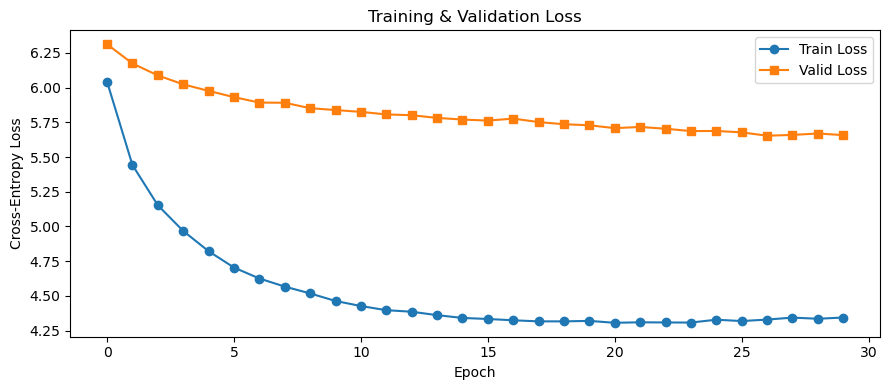

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(valid_losses, marker="s", label="Valid Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

## Cell 18. 최적 모델 로드 & 최종 테스트

저장해 둔 최적 가중치를 불러와 최종 번역 성능을 확인하고,
Attention 히트맵으로 모델이 어느 소스 토큰에 집중했는지 시각화합니다.


✓ 모델 로드 완료: best_model.pt


──────────────────────────────────────────────────
  번역 테스트 [최종 결과]
──────────────────────────────────────────────────
  KO: 오바마는 대통령이다.
  EN: Obama is president. president. president. president.

  KO: 시민들은 도시 속에 산다.
  EN: Citizens the urban

  KO: 커피는 필요 없다.
  EN: Coffee

  KO: 일곱 명의 사망자가 발생했다.
  EN: Were the of


[단일 문장 비교]
KO: 오바마는 대통령이다.
Greedy EN: Obama is president. president. president. president.
Beam   EN: Obama is president. president. president. president.


/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_127/1567257747.py:75: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

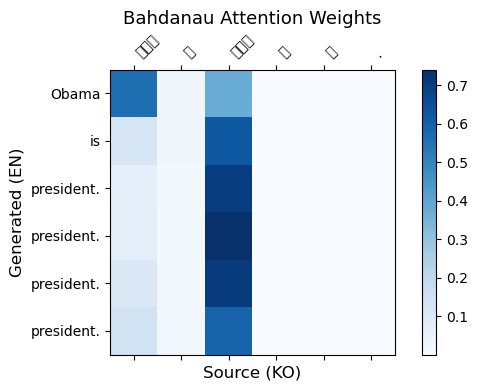

In [35]:
# 최적 가중치 로드
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print(f"✓ 모델 로드 완료: {SAVE_PATH}\n")

# Greedy 번역 테스트
test_translation(model)

# Beam Search 번역 테스트
sample = "오바마는 대통령이다."
greedy_result, src_toks, greedy_attn = translate(sample, model)
beam_result, _, beam_attn = beam_search_translate(sample, model, beam_size=3)

print("\n[단일 문장 비교]")
print(f"KO: {sample}")
print(f"Greedy EN: {greedy_result}")
print(f"Beam   EN: {beam_result}")

# Attention 시각화는 Beam Search 결과 기준으로 출력합니다.
if beam_attn is not None:
    show_attention(src_toks, beam_result.split(), beam_attn)


## 회고

이번 프로젝트를 하면서 번역 모델을 만드는 과정이 생각보다 복잡하다는 것을 느꼈다.  
처음에는 모델 구조를 만들고 학습만 시키면 번역이 어느 정도 잘될 것이라고 생각했다.  
하지만 실제로 결과를 확인해 보니, 학습은 진행되었지만 번역 문장이 어색하거나 같은 단어가 반복되는 문제가 있었다.

이 과정을 통해 딥러닝에서는 코드가 실행되는 것만으로는 충분하지 않다는 것을 알게 되었다.  
모델이 실제로 어떤 데이터를 보고 학습하는지, 입력과 정답이 제대로 만들어졌는지 확인하는 과정이 매우 중요했다.

특히 `<start>`와 `<end>` 같은 특수 토큰이 중요하다는 것을 알게 되었다.  
이 토큰은 번역 문장이 어디서 시작하고 어디서 끝나는지 알려주는 역할을 한다.  
이 부분이 제대로 처리되지 않으면 모델이 문장을 자연스럽게 끝내지 못하고, 같은 단어를 반복할 수 있다는 점을 배웠다.

또한 Attention 구조를 사용하면서 모델이 번역할 때 입력 문장의 어느 부분을 참고하는지 확인할 수 있었다.  
단순히 문장을 외워서 번역하는 것이 아니라, 필요한 부분을 참고하면서 단어를 만들어 낸다는 점이 인상적이었다.

이번 작업에서 아쉬웠던 점은 최종 번역 결과가 기대만큼 자연스럽지 않았다는 것이다.  
일부 문장은 의미가 어느 정도 통했지만, 전체적으로는 아직 부족한 결과가 많았다.  
그래도 데이터 전처리, 토큰화, 모델 구성, 학습, 추론까지 전체 과정을 직접 해 보면서 자연어 처리 모델이 어떻게 만들어지는지 이해할 수 있었다.

다음에 비슷한 작업을 한다면, 학습을 시작하기 전에 데이터가 제대로 전처리되었는지 먼저 확인할 것이다.  
특히 입력 문장과 정답 문장, 시작 토큰과 종료 토큰이 올바르게 들어갔는지 확인한 뒤 학습을 진행해야겠다고 느꼈다.

이번 프로젝트는 완성도 높은 번역기를 만들기에는 부족한 점이 있었지만, Seq2Seq와 Attention 모델의 기본 흐름을 이해하는 데 도움이 되었다.